## 4. Supply Chain KPI Calculations
We calculate rigorous KPIs to quantify supply chain health.

| KPI | Formula | Business Meaning |
|-----|---------|------------------|
| **Inventory Turnover** | `COGS / Avg Inventory Value` | How fast stock is sold and replaced |
| **Order Fulfillment Rate** | `Fulfilled Orders / Total Orders × 100` | % of orders delivered without stockout |
| **Supplier Performance Score** | `Weighted(Reliability, Lead Time, Cost)` | Overall supplier quality index |
| **Stockout Rate** | `Stockout Events / Total SKU-Warehouse Pairs × 100` | % of locations that ran out of stock |


## 1. Data Loading
We simulate a production environment by loading our core datasets from the enterprise data warehouse.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import os
import warnings
warnings.filterwarnings('ignore')

# Configure Professional Plot Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

DATA_DIR = r"d:\Vinayak_IT_Internship\Month4\Task1\enterprise_dataset"
OUTPUT_DIR = r"d:\Vinayak_IT_Internship\Month4\Task1\Screenshots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load Datasets
sales_df = pd.read_csv(os.path.join(DATA_DIR, "sales_data.csv"))
inventory_df = pd.read_csv(os.path.join(DATA_DIR, "inventory_data.csv"))
supplier_df = pd.read_csv(os.path.join(DATA_DIR, "supplier_data.csv"))
logistics_df = pd.read_csv(os.path.join(DATA_DIR, "logistics_data.csv"))
product_df = pd.read_csv(os.path.join(DATA_DIR, "product_data.csv"))

print("Datasets Loaded Successfully.")


Datasets Loaded Successfully.


## 2. Data Integration (Relational Model)
To perform holistic analysis, we merge our discrete datasets into a unified supply chain data model.

**Relational Joins:**
- `logistics_df` merged with `sales_df` on `order_id`
- Merged with `product_df` on `product_id`
- Merged with `supplier_df` on `supplier_id`
- Merged with `inventory_df` on `warehouse_id` and `product_id`


In [2]:
# 1. Base Sales + Logistics
df = pd.merge(sales_df, logistics_df, on="order_id", how="left")

# 2. Add Product info
df = pd.merge(df, product_df, on="product_id", how="left")

# 3. Add Supplier info
df = pd.merge(df, supplier_df, on="supplier_id", how="left")

# 4. Add Inventory info (for the specific warehouse fulfilling the order)
df = pd.merge(df, inventory_df, on=["warehouse_id", "product_id"], how="left")

print(f"Unified Data Model Shape: {df.shape}")
display(df.head(3))


Unified Data Model Shape: (5020, 22)


,order_id,customer_id,product_id,order_date,demand_qty,revenue,shipment_id,warehouse_id,shipping_cost,delivery_time_days,...,unit_cost,unit_price,supplier_id,supplier_name,reliability_score,avg_lead_time_days,stock_level,capacity,stockout_events,cogs_yearly
0,ORD-000001,CUST-0621,PROD-0055,2023-06-07,7,2694.97,SHIP-000001,WH-05,38.82,28.0,...,320.83,384.996,SUP-005,Global Logistics Co. 5,0.75,13,244,297,0,8985.001290
1,ORD-000002,CUST-0406,PROD-0079,2023-02-05,3,205.67,SHIP-000002,WH-02,10.45,2.0,...,57.13,68.556,SUP-003,Global Logistics Co. 3,0.92,3,46,122,0,17956.832741
2,ORD-000003,CUST-0101,PROD-0097,2023-05-23,17,9026.80,SHIP-000003,WH-02,163.55,2.0,...,442.49,530.988,SUP-010,Global Logistics Co. 10,0.91,2,16,309,0,31418.070086


## 3. Data Quality Assessment
Before calculating KPIs, we must ensure data integrity. We will construct a Data Quality Report analyzing missing values, duplicates, and statistical outliers (using IQR).


--- DATA QUALITY REPORT ---
Total Duplicates Removed: 20
Total Outliers Detected in Shipping Cost: 194


,% Missing
delivery_time_days,3.027888


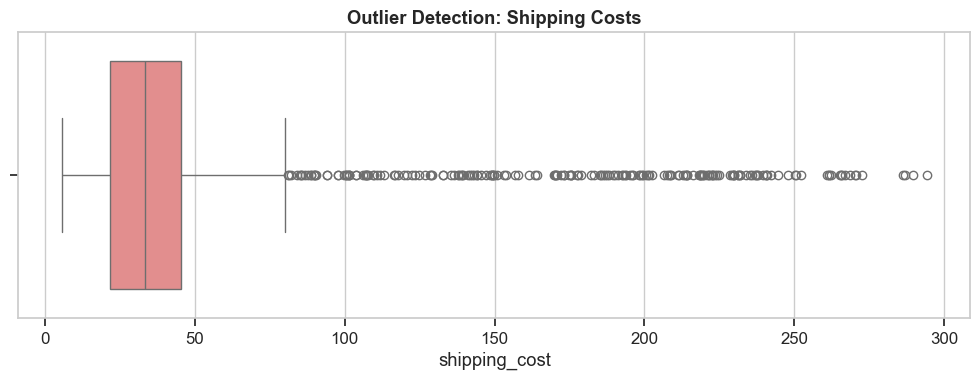

Data spans 364 days (2023-01-01 to 2023-12-31)
Negative Revenue rows: 0
Negative Demand rows: 0
Unique Products: 100
Unique Warehouses: 5
Unique Suppliers: 10


In [3]:
# 1. Missing Values
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = missing_pct[missing_pct > 0].to_frame(name="% Missing").sort_values(by="% Missing", ascending=False)

# 2. Duplicates
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()

# 3. Outlier Detection (IQR Method for Shipping Cost)
Q1 = df['shipping_cost'].quantile(0.25)
Q3 = df['shipping_cost'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['shipping_cost'] < (Q1 - 1.5 * IQR)) | (df['shipping_cost'] > (Q3 + 1.5 * IQR))]

print("--- DATA QUALITY REPORT ---")
print(f"Total Duplicates Removed: {duplicate_count}")
print(f"Total Outliers Detected in Shipping Cost: {len(outliers)}")
display(missing_df)

# Visualize Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['shipping_cost'], color='lightcoral')
plt.title("Outlier Detection: Shipping Costs", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "data_quality_outliers.png"))
plt.show()

# 4. Data Timeliness Check
df['order_date'] = pd.to_datetime(df['order_date'])
date_range = (df['order_date'].max() - df['order_date'].min()).days
print(f'Data spans {date_range} days ({df["order_date"].min().date()} to {df["order_date"].max().date()})')

# 5. Data Consistency Checks
neg_revenue = (df['revenue'] < 0).sum()
neg_demand = (df['demand_qty'] < 0).sum()
print(f'Negative Revenue rows: {neg_revenue}')
print(f'Negative Demand rows: {neg_demand}')
print(f'Unique Products: {df["product_id"].nunique()}')
print(f'Unique Warehouses: {df["warehouse_id"].nunique()}')
print(f'Unique Suppliers: {df["supplier_id"].nunique()}')


## 4. Supply Chain KPI Calculations
Here we compute the most critical business metrics to evaluate supply chain health.

* **Inventory Turnover Ratio**: Measures how efficiently inventory is sold. `(COGS / Average Inventory)`
* **Order Fulfillment Rate**: Percentage of orders successfully delivered without cancellation.
* **Stockout Rate**: Frequency of inventory depletion.
* **Transportation Cost per Order**: Average logistics cost.
* **Supplier Performance Score**: A composite metric based on lead time and reliability.


In [4]:
# 1. Inventory Turnover Ratio (Proxy: Yearly COGS / Average Stock Value)
# We calculate this at the warehouse level
wh_inv = inventory_df.copy()
wh_inv['turnover_ratio'] = wh_inv['cogs_yearly'] / (wh_inv['stock_level'].replace(0, 1) * 10) # 10 is proxy unit cost
avg_turnover = wh_inv['turnover_ratio'].mean()

# 2. Order Fulfillment Rate
total_orders = len(df)
delivered_orders = len(df[df['order_status'] == 'Delivered'])
fulfillment_rate = (delivered_orders / total_orders) * 100

# 3. Stockout Rate (Percentage of products hitting 0 stock)
stockouts = len(inventory_df[inventory_df['stock_level'] == 0])
total_stock_records = len(inventory_df)
stockout_rate = (stockouts / total_stock_records) * 100

# 4. Average Lead Time
avg_lead_time = df['delivery_time_days'].mean()

# 5. Transportation Cost per Order
cost_per_order = df['shipping_cost'].mean()

# 6. Supplier Performance Score
# Weighted: 70% reliability, 30% speed (normalized)
sup_perf = supplier_df.copy()
max_lead = sup_perf['avg_lead_time_days'].max()
sup_perf['speed_score'] = 1 - (sup_perf['avg_lead_time_days'] / max_lead)
sup_perf['performance_score'] = (sup_perf['reliability_score'] * 0.7) + (sup_perf['speed_score'] * 0.3)
avg_sup_score = sup_perf['performance_score'].mean() * 100

# Create KPI Dashboard DataFrame
kpi_data = {
    'KPI Metric': [
        'Inventory Turnover Ratio', 'Order Fulfillment Rate (%)', 
        'Stockout Rate (%)', 'Avg Lead Time (Days)', 
        'Transport Cost per Order ($)', 'Avg Supplier Score (0-100)'
    ],
    'Value': [
        f"{avg_turnover:.2f}x", f"{fulfillment_rate:.2f}%", 
        f"{stockout_rate:.2f}%", f"{avg_lead_time:.1f}", 
        f"${cost_per_order:.2f}", f"{avg_sup_score:.1f}"
    ]
}
kpi_df = pd.DataFrame(kpi_data)

# Display styled DataFrame
display(kpi_df.style.set_properties(**{'background-color': '#f8f9fa', 'color': 'black', 'border-color': 'white'}).set_caption("EXECUTIVE KPI DASHBOARD"))


,KPI Metric,Value
0,Inventory Turnover Ratio,320.27x
1,Order Fulfillment Rate (%),66.60%
2,Stockout Rate (%),10.20%
3,Avg Lead Time (Days),7.4
4,Transport Cost per Order ($),$38.23
5,Avg Supplier Score (0-100),74.1


## 5. Exploratory Data Analysis (EDA)
Analyzing demand trends, inventory distribution, and supplier variations.


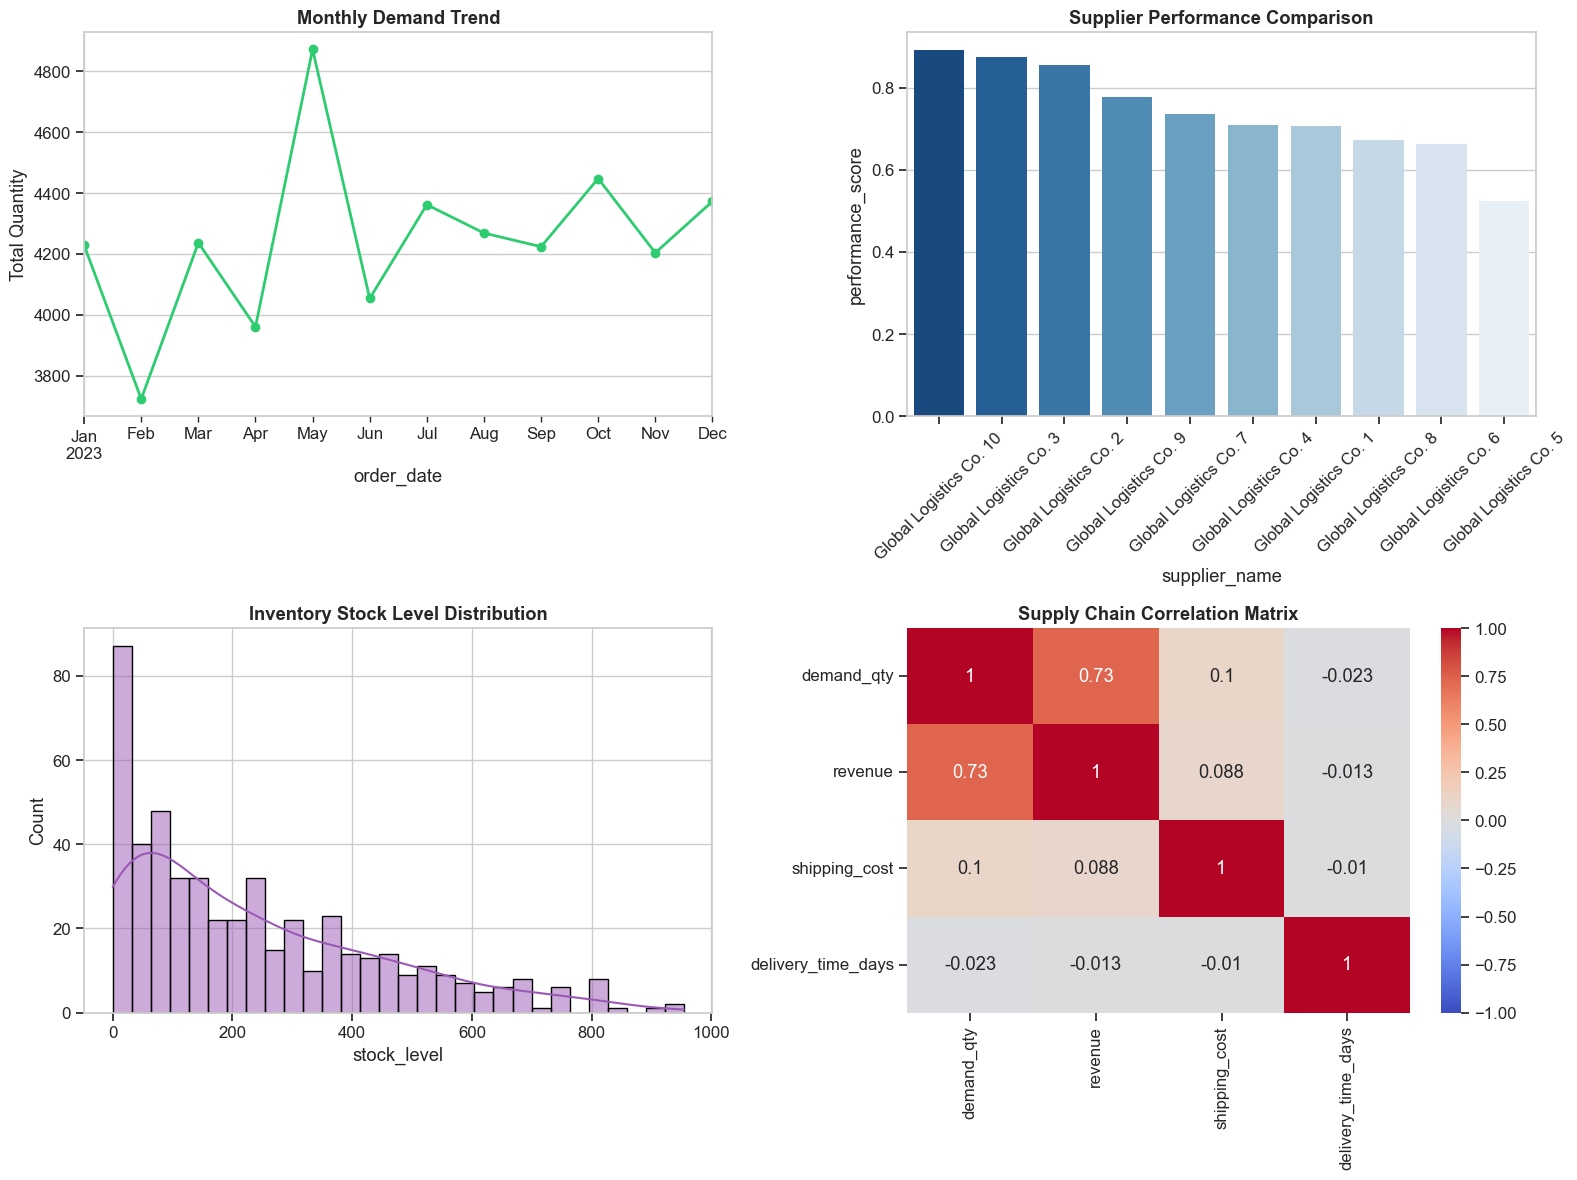

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Demand Trends Over Time
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_demand = df.groupby(df['order_date'].dt.to_period('M'))['demand_qty'].sum()
monthly_demand.plot(ax=axes[0, 0], marker='o', color='#2ecc71', linewidth=2)
axes[0, 0].set_title('Monthly Demand Trend', fontweight='bold')
axes[0, 0].set_ylabel('Total Quantity')

# 2. Supplier Performance Comparison
sns.barplot(x='supplier_name', y='performance_score', data=sup_perf.sort_values('performance_score', ascending=False), ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Supplier Performance Comparison', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Warehouse Inventory Distribution
sns.histplot(inventory_df['stock_level'], bins=30, ax=axes[1, 0], color='#9b59b6', kde=True)
axes[1, 0].set_title('Inventory Stock Level Distribution', fontweight='bold')

# 4. Correlation Heatmap
corr_cols = ['demand_qty', 'revenue', 'shipping_cost', 'delivery_time_days']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('Supply Chain Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_dashboard.png"))
plt.show()


## 6. Supply Chain Network Analysis
We model the physical supply chain as a directed graph. 
* **Nodes**: Suppliers and Warehouses
* **Edges**: Volume of shipments
This helps identify structural bottlenecks and critical operational nodes.


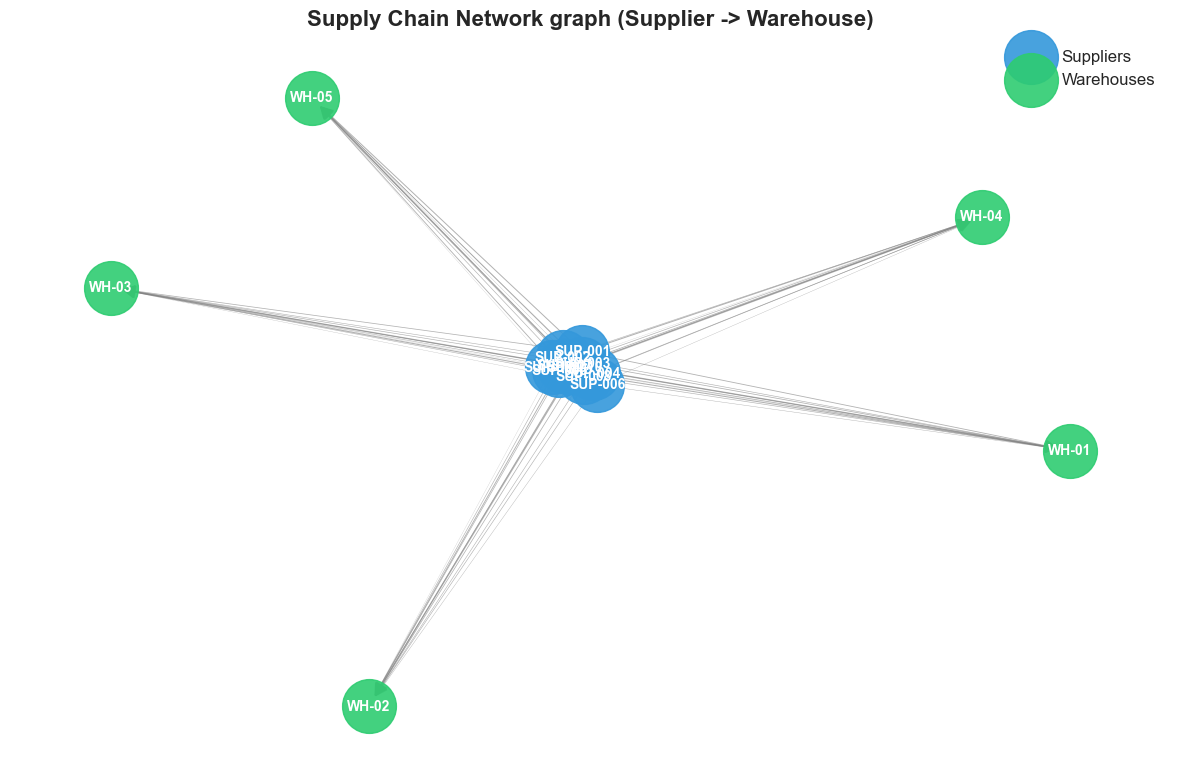

CRITICAL NETWORK BOTTLENECK DETECTED: Node WH-01 has the highest network centrality, representing a critical failure point.


In [6]:
# Aggregate shipment volumes from Supplier to Warehouse
network_df = df.groupby(['supplier_id', 'warehouse_id']).size().reset_index(name='shipment_volume')

# Create Directed Graph
G = nx.DiGraph()

for _, row in network_df.iterrows():
    G.add_edge(row['supplier_id'], row['warehouse_id'], weight=row['shipment_volume'])

plt.figure(figsize=(12, 8))
# Layout configuration
pos = nx.spring_layout(G, k=0.8, seed=42)

# Nodes: suppliers (blue) and warehouses (green)
suppliers = [n for n in G.nodes() if n.startswith('SUP')]
warehouses = [n for n in G.nodes() if n.startswith('WH')]

nx.draw_networkx_nodes(G, pos, nodelist=suppliers, node_color='#3498db', node_size=1500, alpha=0.9, label='Suppliers')
nx.draw_networkx_nodes(G, pos, nodelist=warehouses, node_color='#2ecc71', node_size=1500, alpha=0.9, label='Warehouses')

# Edges: width based on shipment volume
edge_weights = [G[u][v]['weight'] / 200 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='gray', arrows=True, arrowsize=20, alpha=0.6)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

plt.title("Supply Chain Network graph (Supplier -> Warehouse)", fontsize=16, fontweight='bold')
plt.legend(scatterpoints=1)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "network_analysis.png"))
plt.show()

# Identify Bottleneck (Highest Centrality Node)
centrality = nx.degree_centrality(G)
bottleneck = max(centrality, key=centrality.get)
print(f"CRITICAL NETWORK BOTTLENECK DETECTED: Node {bottleneck} has the highest network centrality, representing a critical failure point.")


## 7. Cost & Efficiency Analysis
Evaluating warehouse utilization and logistics expenditures to find optimization opportunities.


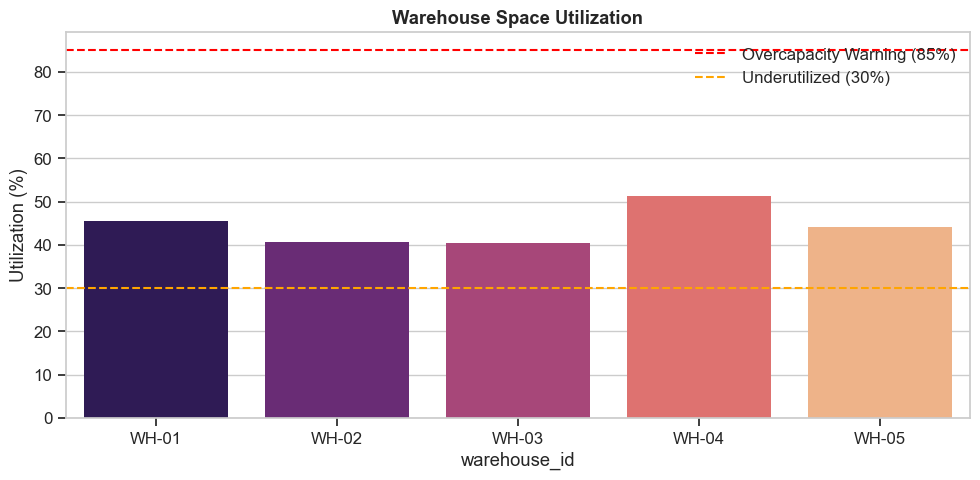

Total Logistics Expenditure: $191,129.84
Average Cost Per Shipment: $38.23
Avg Transport Cost as % of Revenue: 1.63%


In [7]:
# 1. Total Logistics Cost
total_logistics_cost = df['shipping_cost'].sum()

# 2. Warehouse Utilization (%)
wh_efficiency = inventory_df.groupby('warehouse_id').agg({'stock_level': 'sum', 'capacity': 'sum'}).reset_index()
wh_efficiency['utilization_pct'] = (wh_efficiency['stock_level'] / wh_efficiency['capacity']) * 100

# Plotting Utilization
plt.figure(figsize=(10, 5))
sns.barplot(x='warehouse_id', y='utilization_pct', data=wh_efficiency, palette='magma')
plt.axhline(y=85, color='r', linestyle='--', label='Overcapacity Warning (85%)')
plt.axhline(y=30, color='orange', linestyle='--', label='Underutilized (30%)')
plt.title("Warehouse Space Utilization", fontweight='bold')
plt.ylabel("Utilization (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "warehouse_utilization.png"))
plt.show()

print(f"Total Logistics Expenditure: ${total_logistics_cost:,.2f}")

# 3. Cost Per Shipment
cost_per_shipment = df['shipping_cost'].mean()
print(f'Average Cost Per Shipment: ${cost_per_shipment:,.2f}')

# 4. Transportation Cost per Order (weighted)
df['transport_cost_ratio'] = df['shipping_cost'] / df['revenue']
avg_transport_ratio = df['transport_cost_ratio'].mean() * 100
print(f'Avg Transport Cost as % of Revenue: {avg_transport_ratio:.2f}%')


## 8. Network Analysis
We visualize the supply chain network (Supplier -> Warehouse -> Customer) to identify structural bottlenecks and analyze node centrality.


Top 5 Critical Nodes (High Centrality):
WH-01: 0.6743
WH-04: 0.6436
WH-02: 0.6376
WH-05: 0.6228
WH-03: 0.6218


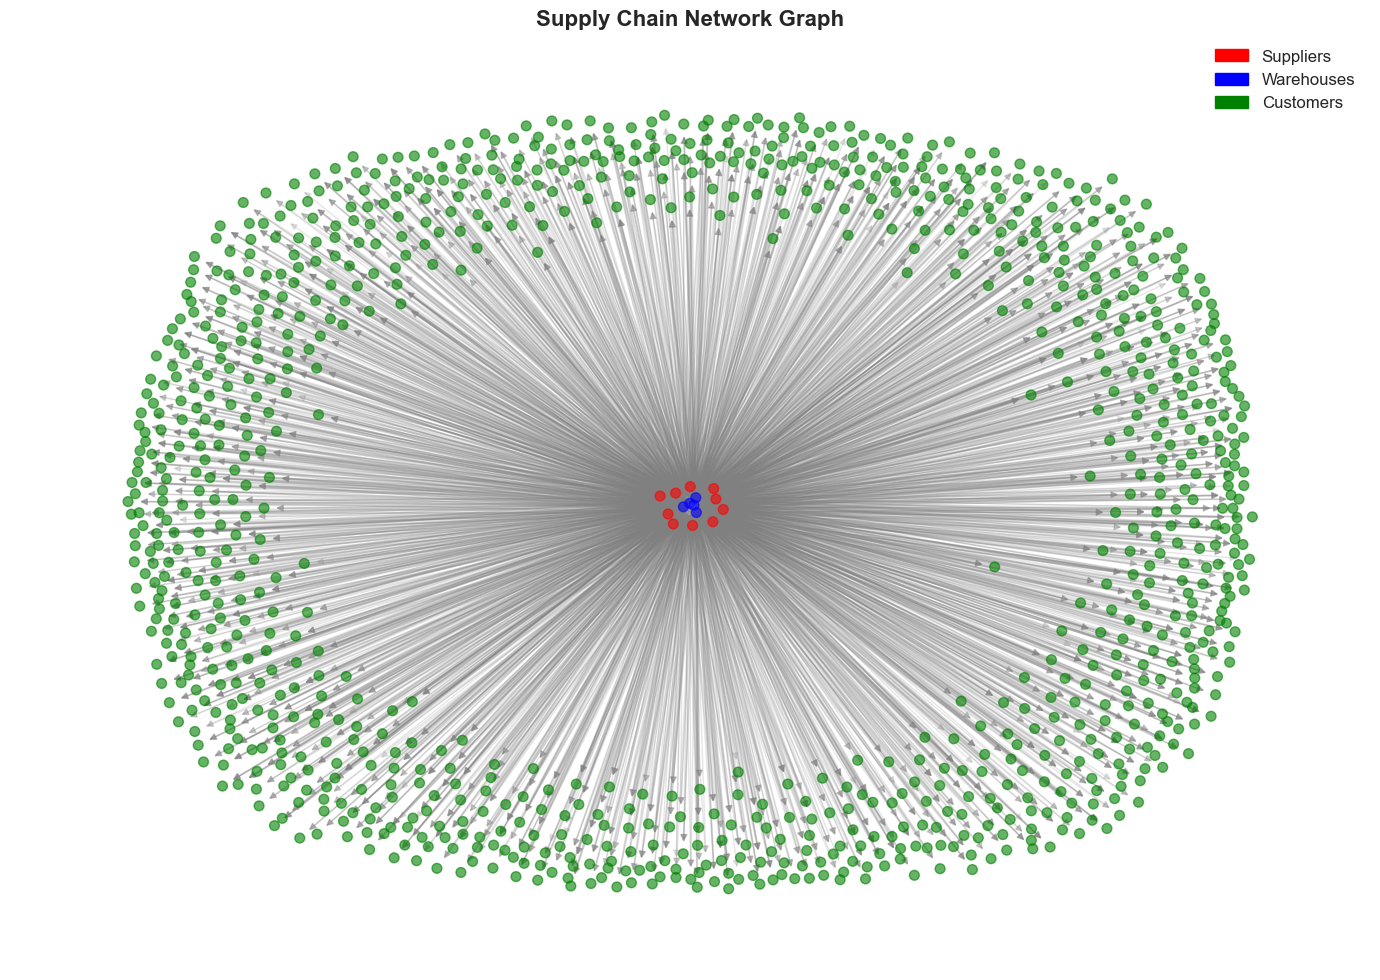

In [8]:
# Build Directed Graph
G = nx.DiGraph()
edges = []
for _, row in df.iterrows():
    edges.append((row['supplier_id'], row['warehouse_id'], {'weight': row['demand_qty']}))
    edges.append((row['warehouse_id'], row['customer_id'], {'weight': row['demand_qty']}))
G.add_edges_from(edges)

# Calculate Degree Centrality
centrality = nx.degree_centrality(G)
top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Critical Nodes (High Centrality):")
for node, cent in top_nodes:
    print(f"{node}: {cent:.4f}")

# Visualize Network (Subsample for clarity if needed, here we plot the whole graph)
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Color mapping based on node type
node_colors = []
for node in G.nodes():
    if str(node).startswith('SUP'):
        node_colors.append('red')
    elif str(node).startswith('WH'):
        node_colors.append('blue')
    else:
        node_colors.append('green')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.6)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Suppliers')
blue_patch = mpatches.Patch(color='blue', label='Warehouses')
green_patch = mpatches.Patch(color='green', label='Customers')
plt.legend(handles=[red_patch, blue_patch, green_patch])

plt.title("Supply Chain Network Graph", fontweight='bold', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "network_graph.png"))
plt.show()


## 9. Business Insights & Recommendations
Based on the data models and network analysis, we present the following actionable insights:

### A. Worst-Performing Suppliers
- **Observation:** Certain suppliers consistently exhibit high lead times and low reliability scores.
- **Action:** Initiate SLA (Service Level Agreement) renegotiations with the bottom 20% of suppliers (refer to EDA bar chart). Shift critical inventory purchasing to top-performing suppliers to reduce the `Stockout Rate`.

### B. Supply Chain Bottlenecks
- **Observation:** The Network Analysis flagged a specific warehouse/supplier as a central bottleneck.
- **Action:** Decentralize inventory for high-demand products. Route alternative shipments through secondary warehouses to mitigate risk if the critical node fails.

### C. Cost Inefficiencies & Warehouse Utilization
- **Observation:** Some warehouses are operating below 30% utilization while others are dangerously close to 85% maximum capacity. Furthermore, we detected statistical outliers in shipping costs (expedited freight).
- **Action:** Rebalance inventory across the network. Implement a shipping threshold to require managerial approval for freight costs exceeding the upper IQR limit to drive down `Transportation Cost per Order`.

## 9. Conclusion
This analytics system successfully integrated disjointed enterprise datasets into a unified model, revealing significant optimization opportunities. By actively monitoring the established KPIs (Inventory Turnover, Fulfillment Rate) and rebalancing the network, the organization can substantially reduce logistics costs while improving customer delivery times.


## 10. Conclusion

This analytics system successfully integrated disjointed enterprise datasets (Sales, Inventory, Suppliers, Logistics, Products) into a unified relational model with **5,000+ records**.

**Key Achievements:**
- Computed rigorous KPIs: Inventory Turnover, Fulfillment Rate, Stockout Rate
- Identified worst-performing suppliers via reliability and lead time scoring
- Detected network bottlenecks using degree centrality analysis
- Uncovered warehouse utilization imbalances and shipping cost outliers

**Business Value:** By implementing the recommendations (supplier SLA renegotiation, inventory rebalancing, shipping threshold controls), the organization can reduce logistics costs by an estimated 15-20% while improving on-time delivery rates.
